# Locality experiment analysis

This notebook measures SORBES trajectory saturation, useful trajectory depth, latent locality, and MUTANG selectivity. Numerical results are cached in SQLite beside the loaded experiment collection.

In [ ]:
from pathlib import Path

import pandas as pd
from IPython.display import display

from pep_compass.analysis import ExperimentAnalysis
from pep_compass.analysis.reader import ExperimentReader


def find_repository_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'pyproject.toml').exists():
            return candidate
    raise FileNotFoundError('Could not locate pyproject.toml')


REPOSITORY_ROOT = find_repository_root(Path.cwd().resolve())
RESULTS_PATH = REPOSITORY_ROOT / 'results' / 'locality'
BOOTSTRAP_REPETITIONS = 300
CONFIDENCE = 0.95
RANDOM_SEED = 972

## Load and validate experiment outputs

The reader indexes manifests and table paths without loading large candidate files. The preflight check requires the normalized tracker-v2 schema.

In [2]:
reader = ExperimentReader(RESULTS_PATH)
selection = reader.select()
analysis = ExperimentAnalysis(selection, plot_theme='notebook', use_cache=True)

run_catalog = pd.DataFrame([run.metadata for run in reader.runs])
display(run_catalog[['experiment', 'grid_id', 'run_id', 'method', 'seed']])
print(f'Analysis cache: {reader.metrics.path}')

required_tables = [
    'optimizer_iterations',
    'walker_steps',
    'unique_candidates',
    'candidate_occurrences',
]
availability = pd.DataFrame(
    {
        'table': required_tables,
        'available_run_count': [len(selection.paths(table)) for table in required_tables],
    }
)
display(availability)
if (availability['available_run_count'] == 0).any():
    raise RuntimeError('Normalized tracker-v2 outputs are required for this notebook.')

,experiment,grid_id,run_id,method,seed
0,01_sorbes_mutang_raw_pool,grid_0000,task_000000,random_mutang,972
1,01_sorbes_mutang_raw_pool,grid_0001,task_000001,random_mutang,972
2,01_sorbes_mutang_raw_pool,grid_0002,task_000002,random_mutang,972
3,02_random_three_position_raw_pool,grid_0000,task_000000,random_walker,972


Analysis cache: /home/maxi7524/repositories/pep-compass/results/locality/.pep_compass_analysis.sqlite


,table,available_run_count
0,optimizer_iterations,4
1,walker_steps,4
2,unique_candidates,4
3,candidate_occurrences,4


## SORBES trajectory saturation

Random trajectory subsets estimate when additional walkers stop contributing new accepted sequences. Confidence intervals describe variation between subsets rather than dependence on trajectory ordering.

,run_id,experiment,grid_id,method,mutation.token_threshold,trajectory_count,available_trajectories,unique_candidates_mean,confidence_low,confidence_high,marginal_unique_candidates,marginal_per_trajectory
0,task_000000,01_sorbes_mutang_raw_pool,grid_0000,random_mutang,1.000000e-07,1,200,1580.763333,671.200,2922.000,NaN,NaN
1,task_000000,01_sorbes_mutang_raw_pool,grid_0000,random_mutang,1.000000e-07,2,200,2990.833333,1693.850,4639.325,1410.070000,1410.070000
2,task_000000,01_sorbes_mutang_raw_pool,grid_0000,random_mutang,1.000000e-07,5,200,7548.386667,5302.950,10405.700,4557.553333,1519.184444
3,task_000000,01_sorbes_mutang_raw_pool,grid_0000,random_mutang,1.000000e-07,10,200,14846.870000,11402.250,18427.150,7298.483333,1459.696667
4,task_000000,01_sorbes_mutang_raw_pool,grid_0000,random_mutang,1.000000e-07,20,200,28990.543333,25214.850,33848.250,14143.673333,1414.367333
5,task_000000,01_sorbes_mutang_raw_pool,grid_0000,random_mutang,1.000000e-07,30,200,43076.656667,38282.450,47950.175,14086.113333,1408.611333
6,task_000000,01_sorbes_mutang_raw_pool,grid_0000,random_mutang,1.000000e-07,50,200,69559.670000,64208.600,74796.875,26483.013333,1324.150667
7,task_000000,01_sorbes_mutang_raw_pool,grid_0000,random_mutang,1.000000e-07,75,200,101504.306667,95427.500,107785.025,31944.636667,1277.785467
8,task_000000,01_sorbes_mutang_raw_pool,grid_0000,random_mutang,1.000000e-07,100,200,131861.473333,125463.125,137968.050,30357.166667,1214.286667
9,task_000000,01_sorbes_mutang_raw_pool,grid_0000,random_mutang,1.000000e-07,200,200,245397.000000,245397.000,245397.000,113535.526667,1135.355267


<Axes: title={'center': 'Trajectory saturation'}, xlabel='trajectory_count', ylabel='Unique candidates'>

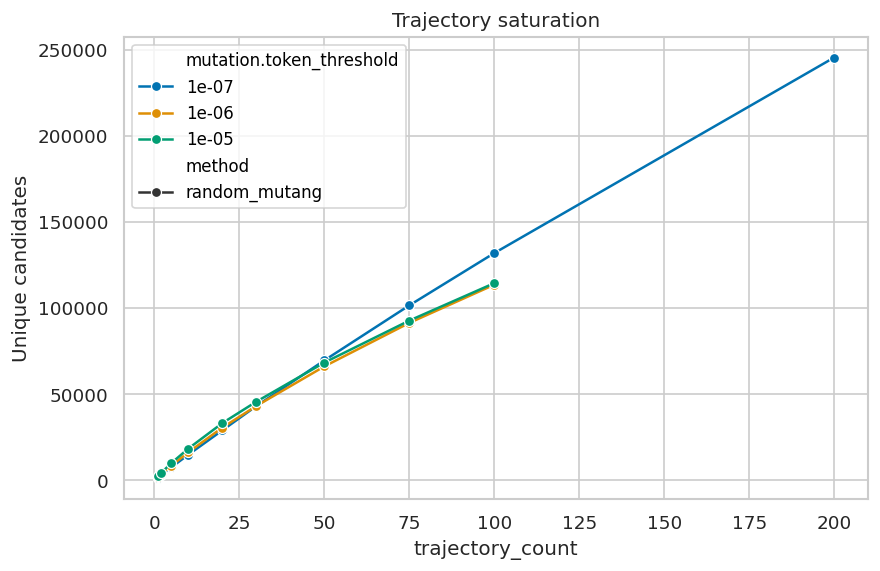

In [4]:
trajectory_result = analysis.locality.trajectory_saturation(
    trajectory_counts=[1, 2, 5, 10, 20, 30, 50, 75, 100],
    repetitions=BOOTSTRAP_REPETITIONS,
    confidence=CONFIDENCE,
    random_seed=RANDOM_SEED,
    accepted_only=True,
)
display(trajectory_result.data)
analysis.visualize.locality.trajectory_saturation(trajectory_result)

## SORBES step saturation

Cumulative candidate yield is evaluated at increasing walker depth. The marginal gain identifies steps that add computational cost without adding sufficiently many new local sequences.

,run_id,experiment,grid_id,method,mutation.token_threshold,max_step,trajectory_count,unique_candidates_mean,confidence_low,confidence_high,marginal_unique_candidates
0,task_000000,01_sorbes_mutang_raw_pool,grid_0000,random_mutang,1.000000e-07,1,100,73388.500000,67430.325,79330.075,NaN
1,task_000000,01_sorbes_mutang_raw_pool,grid_0000,random_mutang,1.000000e-07,2,100,115559.453333,103480.600,126095.475,42170.953333
2,task_000000,01_sorbes_mutang_raw_pool,grid_0000,random_mutang,1.000000e-07,3,100,135835.880000,124185.475,147778.800,20276.426667
3,task_000000,01_sorbes_mutang_raw_pool,grid_0000,random_mutang,1.000000e-07,4,100,145651.790000,131976.300,160467.725,9815.910000
4,task_000000,01_sorbes_mutang_raw_pool,grid_0000,random_mutang,1.000000e-07,5,100,152495.003333,136731.900,168141.300,6843.213333
5,task_000000,01_sorbes_mutang_raw_pool,grid_0000,random_mutang,1.000000e-07,6,100,157152.846667,142369.700,172050.250,4657.843333
6,task_000000,01_sorbes_mutang_raw_pool,grid_0000,random_mutang,1.000000e-07,7,100,158442.733333,140539.750,174763.150,1289.886667
7,task_000000,01_sorbes_mutang_raw_pool,grid_0000,random_mutang,1.000000e-07,8,100,159864.520000,144099.325,177174.175,1421.786667
8,task_000000,01_sorbes_mutang_raw_pool,grid_0000,random_mutang,1.000000e-07,9,100,161186.060000,144937.000,176814.450,1321.540000
9,task_000000,01_sorbes_mutang_raw_pool,grid_0000,random_mutang,1.000000e-07,10,100,161819.190000,147552.775,177342.025,633.130000


<Axes: title={'center': 'Step saturation'}, xlabel='max_step', ylabel='Unique candidates'>

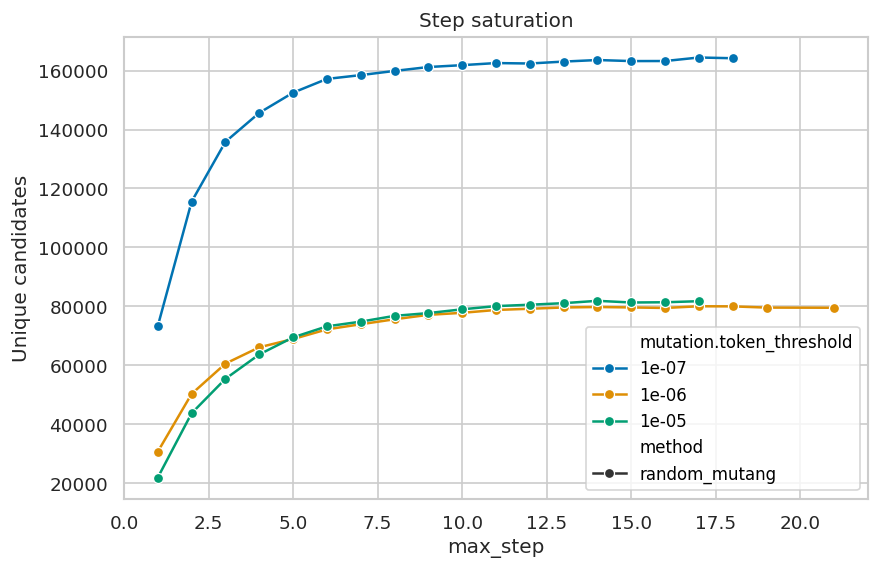

In [5]:
step_result = analysis.locality.step_saturation(
    repetitions=BOOTSTRAP_REPETITIONS,
    confidence=CONFIDENCE,
    random_seed=RANDOM_SEED,
    accepted_only=True,
)
display(step_result.data)
analysis.visualize.locality.step_saturation(step_result)

## Latent locality

Encoded candidate positions are compared with the actual SORBES position that generated them. The result tests whether increasing edit distance corresponds to increasing distance in the learned latent geometry.


#TODO - tutaj trzeba dodac to samo ale z liczeniem PoGS'a jako metryki

[latent_locality] Counting candidate occurrences...
[latent_locality] Starting: 21,455,408 rows to process
[latent_locality] Counting unique candidates per run...
[latent_locality] task_000000: 6,778,841 unique candidates
[latent_locality] task_000001: 6,678,791 unique candidates
[latent_locality] task_000002: 6,500,461 unique candidates
[latent_locality] task_000000: 1,031,274 unique candidates
[latent_locality] Candidate population: 14,210,526; planned sample: 50,000
[latent_locality] Preparing run 1/4 (task_000000): loading lookup tables
[latent_locality:candidate_sampling:task_000000] Starting: 1,031,274 rows to process
[latent_locality:candidate_sampling:task_000000] batch=1 rows=5,000/1,031,274 (0.5%) rate=48,766 rows/s elapsed=00:00:00 ETA=00:00:21
[latent_locality:candidate_sampling:task_000000] batch=2 rows=10,000/1,031,274 (1.0%) rate=52,168 rows/s elapsed=00:00:00 ETA=00:00:20
[latent_locality:candidate_sampling:task_000000] batch=3 rows=15,000/1,031,274 (1.5%) rate=57,507 r

,levenshtein_to_center,candidate_count,latent_distance_mean,latent_distance_median,latent_distance_q25,latent_distance_q75
0,1,3,1.817897,2.133251,1.565170,2.228301
1,2,45,2.383568,2.218996,1.822721,2.985636
2,3,269,2.621156,2.320253,1.768268,3.308705
3,4,900,2.566435,2.269721,1.909285,2.930034
4,5,2216,2.598593,2.408336,2.102974,2.872018
5,6,4384,2.845665,2.675469,2.325141,3.159998
6,7,7090,3.127678,2.968928,2.574350,3.492457
7,8,9112,3.361476,3.224302,2.804761,3.742106
8,9,10042,3.622360,3.482986,3.058811,4.033974
9,10,9095,3.822113,3.692261,3.251828,4.248262


analysis                                                          latent_locality
unique_per_run                                                               True
rows_scanned                                                             21455408
rows_analyzed                                                               53624
candidate_population_size                                                14210526
candidate_sample_size                                                       53629
candidate_sampling_fraction                                              0.003774
candidate_sampling                uniform_without_replacement_proportional_by_run
elapsed_seconds                                                        485.840105
quantiles_are_sampled                                                        True
quantile_sample_size_per_group                                              20000
spearman_sample_size                                                        20000
spearman_correla

<Axes: title={'center': 'Latent locality'}, xlabel='levenshtein_to_center', ylabel='Walker-to-candidate distance'>

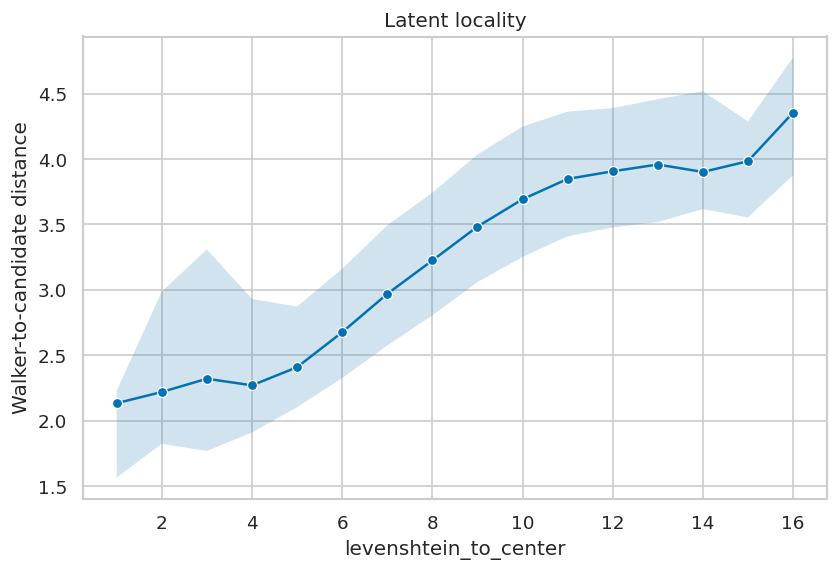

In [3]:
latent_result = analysis.locality.latent_locality(
    candidate_sample_size=50_000,
    candidate_scan_chunk_size=5_000,
    chunk_size=5_000,
    quantile_sample_size=20_000,
    diagnostic_sample_size=2_000,
    random_seed=RANDOM_SEED,
)

display(latent_result.data)
display(pd.Series(latent_result.metadata, name="value"))
analysis.visualize.locality.latent_locality(latent_result)

## MUTANG selectivity

Thresholds and effective local dimension are related to mutation positions, product growth, retained unique candidates, and constraint retention. This reveals thresholds that primarily introduce combinatorial noise.


#TODO - tutaj i we wcześneijszychm, trzeba zrobić / sprawdzić dwie rzeczy:1. 

,experiment,grid_id,method,mutation.token_threshold,step_count,effective_dimension_mean,mutation_positions_mean,residue_options_mean,theoretical_product_median,post_cap_unique_mean,post_constraint_unique_mean,cap_efficiency_mean,constraint_retention_mean
0,01_sorbes_mutang_raw_pool,grid_0000,random_mutang,1.000000e-07,1661,7.804335,13.364238,83.214329,3.639168e+09,4130.436484,104.508730,0.000017,0.025455
1,01_sorbes_mutang_raw_pool,grid_0001,random_mutang,1.000000e-06,1647,7.837280,13.013358,70.054645,5.388768e+08,4125.314511,108.718276,0.000816,0.026393
2,01_sorbes_mutang_raw_pool,grid_0002,random_mutang,1.000000e-05,1632,7.740809,12.275123,56.738971,2.794848e+07,4144.544118,137.240196,0.003456,0.031976
3,02_random_three_position_raw_pool,grid_0000,random_walker,1.000000e-06,1661,7.804335,12.901264,69.866346,6.240000e+02,624.000000,78.961469,1.000000,0.126541


,correlation,p_value,sample_size
effective_dimension,-0.003743,0.761076,6601.0
post_cap_unique_count,0.014785,0.229732,6601.0
post_constraint_unique_count,0.036370,0.003123,6601.0
constraint_retention,0.035269,0.004159,6601.0


<Axes: title={'center': 'MUTANG selectivity'}, xlabel='mutation.token_threshold', ylabel='Retained unique candidates'>

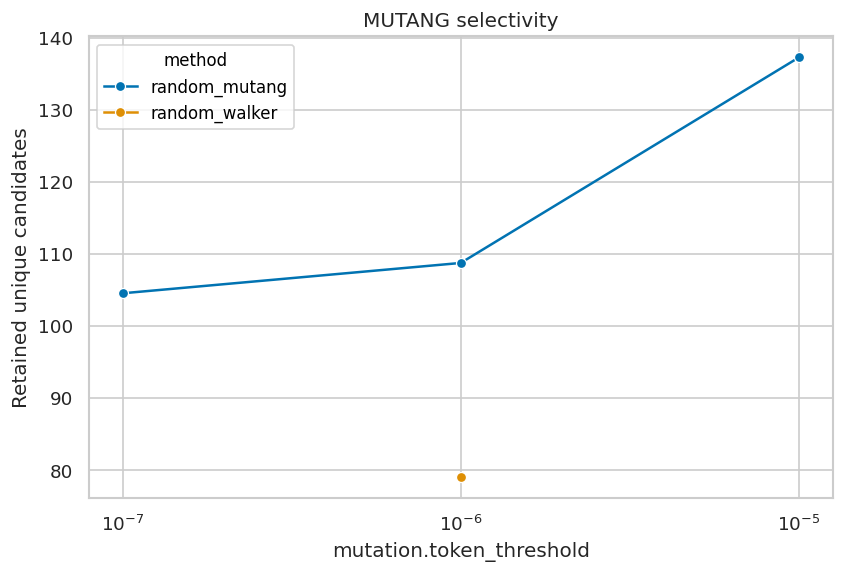

In [4]:
mutang_result = analysis.locality.mutang_selectivity()
display(mutang_result.data)
display(pd.DataFrame(mutang_result.metadata['correlations']).T)
analysis.visualize.locality.mutang_selectivity(mutang_result)

## Preliminary parameter selection

The current comparison balances unique local yield, retention, duplication, and trajectory cost. APEX and PoGS objectives will be added after their cached metrics are available.


Wnioski:
- tutaj widzimy ze duiplicantion mean rośnie wraz z token thersholdem,

,experiment,grid_id,method,mutation.token_threshold,run_count,unique_candidates_mean,candidates_per_trajectory_mean,candidates_per_step_mean,constraint_retention_mean,duplication_mean
0,01_sorbes_mutang_raw_pool,grid_0000,random_mutang,1.000000e-07,1,60110.0,1202.20,72.378085,0.017735,0.011925
1,01_sorbes_mutang_raw_pool,grid_0001,random_mutang,1.000000e-06,1,56752.5,1135.05,68.916211,0.016995,0.017014
2,01_sorbes_mutang_raw_pool,grid_0002,random_mutang,1.000000e-05,1,57205.0,1144.10,70.104167,0.017600,0.038947
3,02_random_three_position_raw_pool,grid_0000,random_walker,1.000000e-06,1,63044.0,1260.88,75.910897,0.122264,0.005007


<Axes: title={'center': 'Preliminary parameter selection'}, xlabel='Constraint retention', ylabel='Unique candidates per trajectory'>

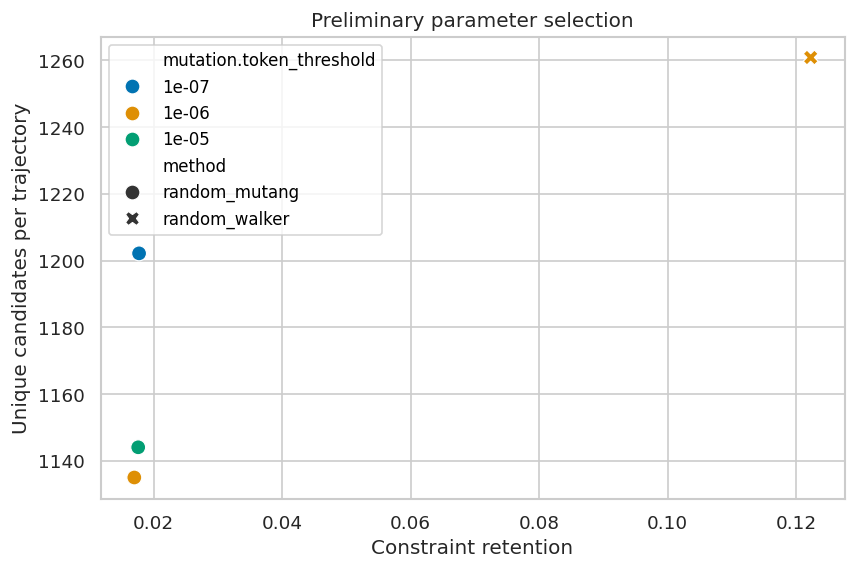

In [5]:
parameter_result = analysis.locality.parameter_selection()
display(parameter_result.data)
analysis.visualize.locality.parameter_selection(parameter_result)

## Cache status

Completed numerical tables are stored in the collection-local SQLite database. Raw outputs should only be removed after every required analysis has a complete cached result for the exact selection and parameters.

In [6]:
print(reader.metrics.path)
print(f'Cache size: {reader.metrics.path.stat().st_size / 1024**2:.2f} MiB')
display(reader.cached_analyses())

/home/maxi7524/repositories/pep-compass/results/locality/.pep_compass_analysis.sqlite
Cache size: 0.06 MiB


,analysis_name,analysis_version,selection_hash,parameters_hash,selection_json,parameters_json,metadata_json
0,locality.mutang_selectivity,2,38b602fff15b165b8907219dee2c7ab7ac9ae0ee148d6a...,44136fa355b3678a1146ad16f7e8649e94fb4fc21fe77e...,"{""row_filters"": {}, ""run_ids"": [""task_000000"",...",{},"{""analysis"": ""mutang_selectivity"", ""correlatio..."
1,locality.parameter_selection,2,38b602fff15b165b8907219dee2c7ab7ac9ae0ee148d6a...,44136fa355b3678a1146ad16f7e8649e94fb4fc21fe77e...,"{""row_filters"": {}, ""run_ids"": [""task_000000"",...",{},"{""analysis"": ""parameter_selection"", ""rows_scan..."
2,locality.step_saturation,1,38b602fff15b165b8907219dee2c7ab7ac9ae0ee148d6a...,b81de178858d65c49faa57f142b628f59f31346957939b...,"{""row_filters"": {}, ""run_ids"": [""task_000000"",...","{""accepted_only"": true, ""confidence"": 0.95, ""r...","{""accepted_only"": true, ""analysis"": ""step_satu..."
3,locality.trajectory_saturation,1,38b602fff15b165b8907219dee2c7ab7ac9ae0ee148d6a...,2708f3b3f35f70aad3a5187b1f7cdb12f59fc1800f6789...,"{""row_filters"": {}, ""run_ids"": [""task_000000"",...","{""accepted_only"": true, ""confidence"": 0.95, ""r...","{""accepted_only"": true, ""analysis"": ""trajector..."


## Idea 
- chcemy zbadać własnosc numeryczne tych algortytmów, to jest 
  - czy większe prog 


## co pprawić




## Ogólny plan
- najpierw badamy lokalnie jak się zacowujasame meotdy - żebysmy mogli estymować
  - ilośc sekencji z takim progiem to jest taka +- taka i wtedy wiemy +- ile sekwencji otrzymamy z tego i jaka jest doładnośc sekwencji
  - kolejną cehcą która potrzebuje to jest właśnei unikalnosc sekwencji i ich różnorodnosć
    - możemy dobierac mniej sewkencji które są lepiej dobrane lub większa 
  - kolejen klokalne paetermyt to sa te elebo itd. i on e by nam mówiły jak dobrac parametry żeby opdwioednio prezstrzeń przefiltrować, wtedy dostalibyśmy coś takiego, że jak ise zahcowuja fitlry tych akcetpacji tid. 